# 03 — Commute Trends: Tacoma and Yakima

This notebook extends the Seattle analysis from notebook 02 to two other Washington state cities:
**Tacoma** (Pierce County) and **Yakima** (Yakima County). It also plots overall WA workforce
totals and average commute times across all years.

**POWPUMA codes by vintage:**

| City | 2010-based (2012–2021) | 2020-based (2022–2023) |
|------|----------------------|----------------------|
| Tacoma (Pierce Co.) | 11500 | 26100 |
| Yakima (Yakima Co.) | 10900 | 27300 |

**Note:** 2000-based POWPUMA codes (for 2005–2011) are not included here because the
2000-era super-PUMA boundaries don't map cleanly to county-level areas and the
sample sizes are very small (~200–500 person-records per city per year).

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns

DATA_DIR = os.path.abspath(os.path.join('..', 'data'))
DERIVED_DIR = os.path.join(DATA_DIR, 'derived')

YEARS_2010_PUMA = list(range(2012, 2022))   # 2010-based PUMAs
YEARS_2020_PUMA = [2022, 2023]              # 2020-based PUMAs
CITY_YEARS = YEARS_2010_PUMA + YEARS_2020_PUMA  # city-level analysis years

ALL_YEARS = list(range(2005, 2024))          # all downloaded years (for overall WA)

REP_COLS = [f'PWGTP{i}' for i in range(1, 81)]

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (14, 6)

CITIES = {
    'Tacoma': {
        2010: {11500},
        2020: {26100},
    },
    'Yakima': {
        2010: {10900},
        2020: {27300},
    },
}

def get_city_powpumas(city, year):
    if year >= 2022:
        return CITIES[city][2020]
    else:
        return CITIES[city][2010]

print(f'City years: {CITY_YEARS}')

City years: [2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023]


## Shared analysis functions

Same mode harmonization and replicate-weight SE functions as notebook 02.

In [2]:
JWTR_MAP = {
    1: 'Car, truck, or van', 2: 'Bus or trolley bus', 3: 'Streetcar or trolley car',
    4: 'Subway or elevated', 5: 'Railroad', 6: 'Ferryboat', 7: 'Taxicab',
    8: 'Motorcycle', 9: 'Bicycle', 10: 'Walked', 11: 'Worked from home', 12: 'Other method',
}
JWTRNS_MAP = {
    1: 'Car, truck, or van', 2: 'Bus', 3: 'Subway or elevated rail',
    4: 'Long-distance train or commuter rail', 5: 'Light rail, streetcar, or trolley',
    6: 'Ferryboat', 7: 'Taxicab', 8: 'Motorcycle', 9: 'Bicycle',
    10: 'Walked', 11: 'Worked from home', 12: 'Other method',
}

def harmonize_modes(df):
    cols = set(df.columns)
    jwtr_col = 'JWTRNS' if 'JWTRNS' in cols else 'JWTR'
    code_map = JWTRNS_MAP if jwtr_col == 'JWTRNS' else JWTR_MAP
    rip_col = 'DRIVESP' if 'DRIVESP' in cols else ('JWRIP' if 'JWRIP' in cols else None)

    df['mode_raw'] = df[jwtr_col].map(code_map)
    is_car = df['mode_raw'].str.contains('Car|car|Van|van|truck', case=False, na=False)
    is_carpool = pd.Series(False, index=df.index)
    if rip_col:
        is_carpool = is_car & df[rip_col].notna() & (df[rip_col] > 1)

    def raw_to_mode(raw, is_cp):
        if pd.isna(raw): return None
        s = str(raw)
        if 'Car' in s or 'Van' in s or 'van' in s or 'truck' in s:
            return 'Carpooled' if is_cp else 'Drove alone'
        if 'Bus' in s or 'bus' in s: return 'Bus'
        if any(k in s for k in ('Subway','Railroad','rail','Light rail','Streetcar','trolley')): return 'Rail/streetcar'
        if 'Ferry' in s or 'ferry' in s: return 'Ferry'
        if 'Bicycle' in s: return 'Bicycle'
        if 'Walked' in s or 'walked' in s: return 'Walked'
        if 'home' in s.lower(): return 'Worked from home'
        return 'Other'

    df['mode'] = [raw_to_mode(r, c) for r, c in zip(df['mode_raw'], is_carpool)]
    return df


def replicate_se(est_full, est_reps):
    est_reps = np.asarray(est_reps, dtype=float)
    return np.sqrt((4.0 / 80.0) * np.nansum((est_reps - est_full) ** 2))

def weighted_proportion_with_se(indicator, weights, rep_df):
    indicator = np.asarray(indicator, dtype=float)
    w = np.asarray(weights, dtype=float)
    p = np.dot(indicator, w) / w.sum()
    p_reps = []
    for c in REP_COLS:
        if c not in rep_df.columns: continue
        wr = np.asarray(rep_df[c], dtype=float)
        d = wr.sum()
        p_reps.append(np.dot(indicator, wr) / d if d > 0 else np.nan)
    return p, replicate_se(p, p_reps)

def weighted_mean_with_se(values, weights, rep_df):
    mask = np.isfinite(values) & np.isfinite(weights)
    v, w = values[mask], weights[mask]
    mean = np.average(v, weights=w)
    rw = rep_df.loc[mask]
    mean_reps = []
    for c in REP_COLS:
        if c not in rw.columns: continue
        wr = np.asarray(rw[c], dtype=float)
        mean_reps.append(np.average(v, weights=wr) if wr.sum() > 0 else np.nan)
    return mean, replicate_se(mean, mean_reps)

print('Functions defined.')

Functions defined.


## Load data

Load all city-range years for Tacoma and Yakima, plus all 2005–2023 years for the overall WA totals.

In [3]:
city_frames = {city: [] for city in CITIES}
overall_frames = []   # all WA workers, all years

for year in ALL_YEARS:
    f = os.path.join(DERIVED_DIR, f'acs_pums_wa_commute_{year}.parquet')
    if not os.path.exists(f):
        print(f'{year}: not found, skipping')
        continue

    df = pd.read_parquet(f)

    # Resolve PUMA column
    for candidate in ['PUMA', 'PUMA10', 'PUMA20', 'PUMA00']:
        if candidate in df.columns and candidate != 'PUMA':
            df['PUMA'] = df[candidate]
            break

    # All WA workers (for overall trend)
    wa_workers = df[df['POWSP'] == 53].copy()
    if len(wa_workers) > 0:
        wa_workers = harmonize_modes(wa_workers)
        wa_workers['YEAR'] = year
        keep = ['YEAR', 'mode', 'JWMNP', 'PWGTP'] + [c for c in REP_COLS if c in wa_workers.columns]
        overall_frames.append(wa_workers[[c for c in keep if c in wa_workers.columns]])

    # City-specific workers (only for years with known POWPUMA codes)
    if year in CITY_YEARS:
        for city in CITIES:
            powpumas = get_city_powpumas(city, year)
            mask = (df['POWSP'] == 53) & (df['POWPUMA'].isin(powpumas))
            workers = df[mask].copy()
            if len(workers) > 0:
                workers = harmonize_modes(workers)
                workers['YEAR'] = year
                keep = ['YEAR', 'PUMA', 'POWPUMA', 'mode', 'JWMNP', 'PWGTP'] + \
                       [c for c in REP_COLS if c in workers.columns]
                city_frames[city].append(workers[[c for c in keep if c in workers.columns]])
            print(f'{year} {city}: {len(workers):>5,} person-records')

city_data = {city: pd.concat(city_frames[city], ignore_index=True) for city in CITIES}
overall_data = pd.concat(overall_frames, ignore_index=True)

print()
for city in CITIES:
    d = city_data[city]
    print(f'{city}: {len(d):,} person-records across {d["YEAR"].nunique()} years')
print(f'Overall WA: {len(overall_data):,} person-records across {overall_data["YEAR"].nunique()} years')

2012 Tacoma: 3,044 person-records
2012 Yakima:   906 person-records


2013 Tacoma: 3,149 person-records
2013 Yakima:   917 person-records


2014 Tacoma: 3,215 person-records
2014 Yakima:   902 person-records


2015 Tacoma: 3,204 person-records
2015 Yakima:   932 person-records


2016 Tacoma: 3,186 person-records
2016 Yakima:   933 person-records


...

2020 Tacoma: 2,816 person-records
2020 Yakima:   747 person-records


2021 Tacoma: 3,698 person-records
2021 Yakima:   953 person-records


2022 Tacoma: 3,340 person-records
2022 Yakima: 1,101 person-records


2023 Tacoma: 3,405 person-records
2023 Yakima: 1,100 person-records



Tacoma: 39,496 person-records across 12 years
Yakima: 11,310 person-records across 12 years
Overall WA: 594,857 person-records across 19 years


## Overall WA workforce trends

Total number of WA workers and the weighted average commute time (excluding WFH), 2005–2023.

In [4]:
overall_rows = []
overall_data['JWMNP'] = pd.to_numeric(overall_data['JWMNP'], errors='coerce')

for year in sorted(overall_data['YEAR'].unique()):
    yr = overall_data[overall_data['YEAR'] == year]
    rep_df = yr[REP_COLS] if REP_COLS[0] in yr.columns else pd.DataFrame()

    # Total workers (weighted)
    total_w = yr['PWGTP'].sum()
    if len(rep_df):
        total_reps = [rep_df[c].sum() for c in REP_COLS if c in rep_df.columns]
        total_se = replicate_se(total_w, total_reps)
    else:
        total_se = np.nan

    # Overall average commute time (exclude WFH and missing)
    commuters = yr[(yr['mode'] != 'Worked from home') & yr['JWMNP'].notna() & (yr['JWMNP'] > 0)]
    if len(commuters) >= 10:
        rep_c = commuters[REP_COLS] if REP_COLS[0] in commuters.columns else pd.DataFrame()
        mean_time, time_se = weighted_mean_with_se(
            commuters['JWMNP'].values, commuters['PWGTP'].values, rep_c
        ) if len(rep_c) else (np.average(commuters['JWMNP'], weights=commuters['PWGTP']), np.nan)
    else:
        mean_time, time_se = np.nan, np.nan

    overall_rows.append({
        'year': year, 'total_workers': total_w, 'total_se': total_se,
        'mean_commute_min': mean_time, 'commute_se': time_se,
    })

overall_trend = pd.DataFrame(overall_rows)
print(overall_trend[['year','total_workers','mean_commute_min']].to_string(index=False))

 year  total_workers  mean_commute_min
 2005        2811188         24.382921
 2006        2922413         24.869048
 2007        2996663         25.462587
 2008        3087723         25.013931
 2009        2988946         24.760066
 2010        2936204         24.636197
 2011        2994118         25.090666
 2012        3079016         25.599893
 2013        3112853         25.801906
 2014        3200706         26.492402
 2015        3265695         26.750794
 2016        3339035         27.441363
 2017        3465104         27.632573
 2018        3558940         28.015784
 2019        3631264         28.316831
 2020        3496716         26.325590
 2021        3582057         25.713284
 2022        3753149         25.867329
 2023        3772373         26.340400


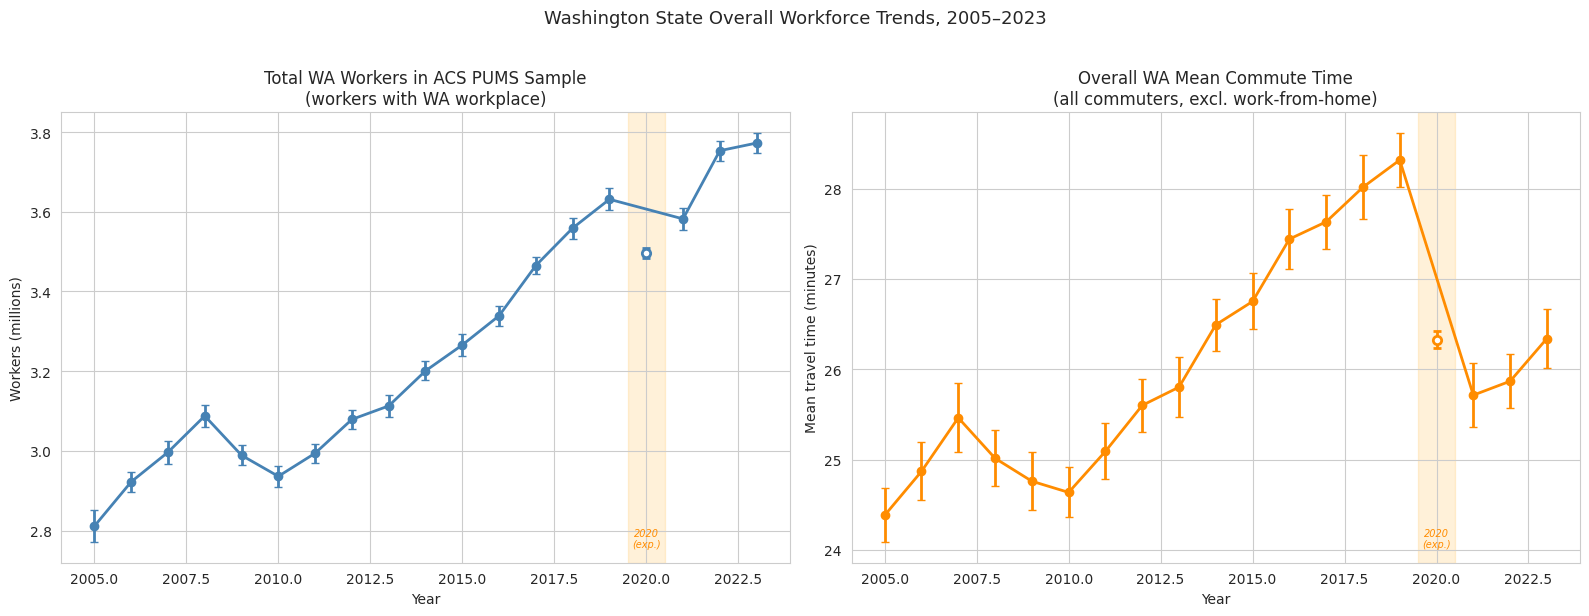

In [5]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

def shade_2020(ax):
    ymin, ymax = ax.get_ylim()
    ax.axvspan(2019.5, 2020.5, alpha=0.15, color='orange', zorder=0)
    ax.text(2020, ymin + (ymax - ymin)*0.03, '2020\n(exp.)',
            fontsize=7, color='darkorange', ha='center', va='bottom', style='italic')

t = overall_trend
reg = t[t['year'] != 2020]
exp = t[t['year'] == 2020]

# Panel 1: total workers
line = ax1.errorbar(reg['year'], reg['total_workers'] / 1e6,
                    yerr=1.96 * reg['total_se'] / 1e6,
                    marker='o', capsize=3, color='steelblue', linewidth=2,
                    label='WA workers')
ax1.errorbar(exp['year'], exp['total_workers'] / 1e6,
             yerr=1.96 * exp['total_se'] / 1e6,
             marker='o', capsize=3, color='steelblue', linewidth=2,
             markerfacecolor='white', markeredgewidth=2)
ax1.set_xlabel('Year')
ax1.set_ylabel('Workers (millions)')
ax1.set_title('Total WA Workers in ACS PUMS Sample\n(workers with WA workplace)')
shade_2020(ax1)

# Panel 2: mean commute time
reg2 = t[t['year'] != 2020]
exp2 = t[t['year'] == 2020]
ax2.errorbar(reg2['year'], reg2['mean_commute_min'],
             yerr=1.96 * reg2['commute_se'],
             marker='o', capsize=3, color='darkorange', linewidth=2,
             label='Mean commute (excl. WFH)')
ax2.errorbar(exp2['year'], exp2['mean_commute_min'],
             yerr=1.96 * exp2['commute_se'],
             marker='o', capsize=3, color='darkorange', linewidth=2,
             markerfacecolor='white', markeredgewidth=2)
ax2.set_xlabel('Year')
ax2.set_ylabel('Mean travel time (minutes)')
ax2.set_title('Overall WA Mean Commute Time\n(all commuters, excl. work-from-home)')
shade_2020(ax2)

plt.suptitle('Washington State Overall Workforce Trends, 2005–2023', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

## Compute mode share and travel time trends by city

Same method as notebook 02: weighted proportions and means with replicate-weight SEs.

In [6]:
MODES_OF_INTEREST = [
    'Drove alone', 'Carpooled', 'Bus', 'Rail/streetcar', 'Ferry',
    'Bicycle', 'Walked', 'Worked from home', 'Other',
]

def compute_mode_trends(workers_df):
    rows = []
    for year in sorted(workers_df['YEAR'].unique()):
        yr = workers_df[workers_df['YEAR'] == year]
        rep_df = yr[REP_COLS] if REP_COLS[0] in yr.columns else pd.DataFrame()
        for mode in MODES_OF_INTEREST:
            indicator = (yr['mode'] == mode).astype(float)
            n_w = (indicator * yr['PWGTP']).sum()
            if len(rep_df):
                frac, frac_se = weighted_proportion_with_se(
                    indicator.values, yr['PWGTP'].values, rep_df
                )
                count_reps = [(indicator.values * rep_df[c].values).sum()
                              for c in REP_COLS if c in rep_df.columns]
                count_se = replicate_se(n_w, count_reps)
            else:
                total_w = yr['PWGTP'].sum()
                frac = n_w / total_w if total_w > 0 else 0
                frac_se = count_se = np.nan
            rows.append({'year': year, 'mode': mode, 'n_weighted': n_w,
                         'n_se': count_se, 'fraction': frac, 'fraction_se': frac_se})
    return pd.DataFrame(rows)


def compute_time_trends(workers_df):
    workers_df = workers_df.copy()
    workers_df['JWMNP'] = pd.to_numeric(workers_df['JWMNP'], errors='coerce')
    # Also compute overall average (all commute modes)
    time_modes = ['Drove alone', 'Bus', 'Carpooled', 'Bicycle', 'Walked', 'Rail/streetcar', 'Ferry', 'Overall']
    rows = []
    for year in sorted(workers_df['YEAR'].unique()):
        yr = workers_df[workers_df['YEAR'] == year]
        for mode in time_modes:
            if mode == 'Overall':
                sub = yr[(yr['mode'] != 'Worked from home') &
                         yr['JWMNP'].notna() & (yr['JWMNP'] > 0)]
            else:
                sub = yr[(yr['mode'] == mode) & yr['JWMNP'].notna() & (yr['JWMNP'] > 0)]
            if len(sub) < 5:
                continue
            rep_df = sub[REP_COLS] if REP_COLS[0] in sub.columns else pd.DataFrame()
            if len(rep_df):
                mean_t, t_se = weighted_mean_with_se(
                    sub['JWMNP'].values, sub['PWGTP'].values, rep_df
                )
            else:
                mean_t = np.average(sub['JWMNP'], weights=sub['PWGTP'])
                t_se = np.nan
            rows.append({'year': year, 'mode': mode, 'mean_min': mean_t,
                         'se': t_se, 'n': len(sub)})
    return pd.DataFrame(rows)


mode_trends = {city: compute_mode_trends(city_data[city]) for city in CITIES}
time_trends = {city: compute_time_trends(city_data[city]) for city in CITIES}

for city in CITIES:
    latest = mode_trends[city]['year'].max()
    top = mode_trends[city][mode_trends[city]['year'] == latest].sort_values('n_weighted', ascending=False)
    print(f'\n{city} — {latest} mode shares:')
    for _, r in top.iterrows():
        print(f"  {r['mode']:<20s}  {r['fraction']*100:5.1f}%")


Tacoma — 2023 mode shares:
  Drove alone            65.7%
  Worked from home       21.0%
  Carpooled               8.6%
  Walked                  1.6%
  Other                   1.4%
  Bus                     1.2%
  Bicycle                 0.3%
  Ferry                   0.1%
  Rail/streetcar          0.0%

Yakima — 2023 mode shares:
  Drove alone            66.4%
  Worked from home       15.9%
  Carpooled               8.6%
  Walked                  3.3%
  Bus                     2.8%
  Other                   1.5%
  Bicycle                 1.4%
  Rail/streetcar          0.1%
  Ferry                   0.0%


## Plot helper

In [7]:
def add_puma_break(ax, x=2021.5, label='PUMA\nchange\n(2010→2020)'):
    ymin, ymax = ax.get_ylim()
    ax.axvline(x=x, color='gray', linestyle='--', alpha=0.5)
    ax.text(x + 0.15, ymax * 0.92, label, fontsize=7, color='gray', va='top')

MAJOR_MODES = ['Drove alone', 'Carpooled', 'Bus', 'Bicycle', 'Walked', 'Worked from home']
MAJOR_TIME_MODES = ['Drove alone', 'Bus', 'Carpooled', 'Walked', 'Overall']

def plot_mode_fractions(ax, mode_trend, city, title_suffix=''):
    for mode in MAJOR_MODES:
        sub = mode_trend[mode_trend['mode'] == mode].sort_values('year')
        if sub['fraction'].sum() < 0.001:
            continue
        line = ax.errorbar(sub['year'], 100 * sub['fraction'],
                           yerr=100 * 1.96 * sub['fraction_se'],
                           marker='o', capsize=3, label=mode, linewidth=2)
    ax.set_xlabel('Year')
    ax.set_ylabel('% of workers')
    ax.set_title(f'{city}: Mode Share{title_suffix}')
    ax.legend(fontsize=8, loc='upper right')
    add_puma_break(ax)

def plot_travel_times(ax, time_trend, city, title_suffix=''):
    for mode in MAJOR_TIME_MODES:
        sub = time_trend[time_trend['mode'] == mode].sort_values('year')
        if len(sub) == 0:
            continue
        lw = 3 if mode == 'Overall' else 2
        ls = '--' if mode == 'Overall' else '-'
        line = ax.errorbar(sub['year'], sub['mean_min'],
                           yerr=1.96 * sub['se'],
                           marker='o', capsize=3, label=mode,
                           linewidth=lw, linestyle=ls)
    ax.set_xlabel('Year')
    ax.set_ylabel('Mean travel time (min)')
    ax.set_title(f'{city}: Mean Commute Time by Mode{title_suffix}')
    ax.legend(fontsize=8, loc='upper right')
    add_puma_break(ax)

def plot_total_workers(ax, mode_trend, city, title_suffix=''):
    # Sum all modes to get total
    totals = mode_trend.groupby('year')['n_weighted'].sum().reset_index()
    # For SE, use sum of SEs in quadrature... actually easier: recompute from data
    # Approximation: take the SE of the total as the SE of the first mode's count
    # Better: compute total from year groups
    year_se = {}
    for year in totals['year']:
        yr_modes = mode_trend[mode_trend['year'] == year]
        # The SE of the total is sqrt(sum of mode count variances) -- but modes are mutually exclusive
        # For mutually exclusive groups, Var(sum) = sum of variances of individual proportions * N^2
        # Easier: use the SE of the total directly from the 'Drove alone' SE as proxy
        # Actually, the total worker count SE is the SE of the total weight = sqrt(4/80 * sum((rep_total - full_total)^2))
        # We'll approximate using the squared SEs of the individual modes
        total_se_sq = (yr_modes['n_se'] ** 2).sum()
        year_se[year] = np.sqrt(total_se_sq)
    totals['se'] = totals['year'].map(year_se)

    ax.errorbar(totals['year'], totals['n_weighted'] / 1e3,
                yerr=1.96 * totals['se'] / 1e3,
                marker='o', capsize=3, color='steelblue', linewidth=2)
    ax.set_xlabel('Year')
    ax.set_ylabel('Workers (thousands, est.)')
    ax.set_title(f'{city}: Total Workers{title_suffix}')
    add_puma_break(ax)

print('Plot helpers defined.')

Plot helpers defined.


## Tacoma (Pierce County)

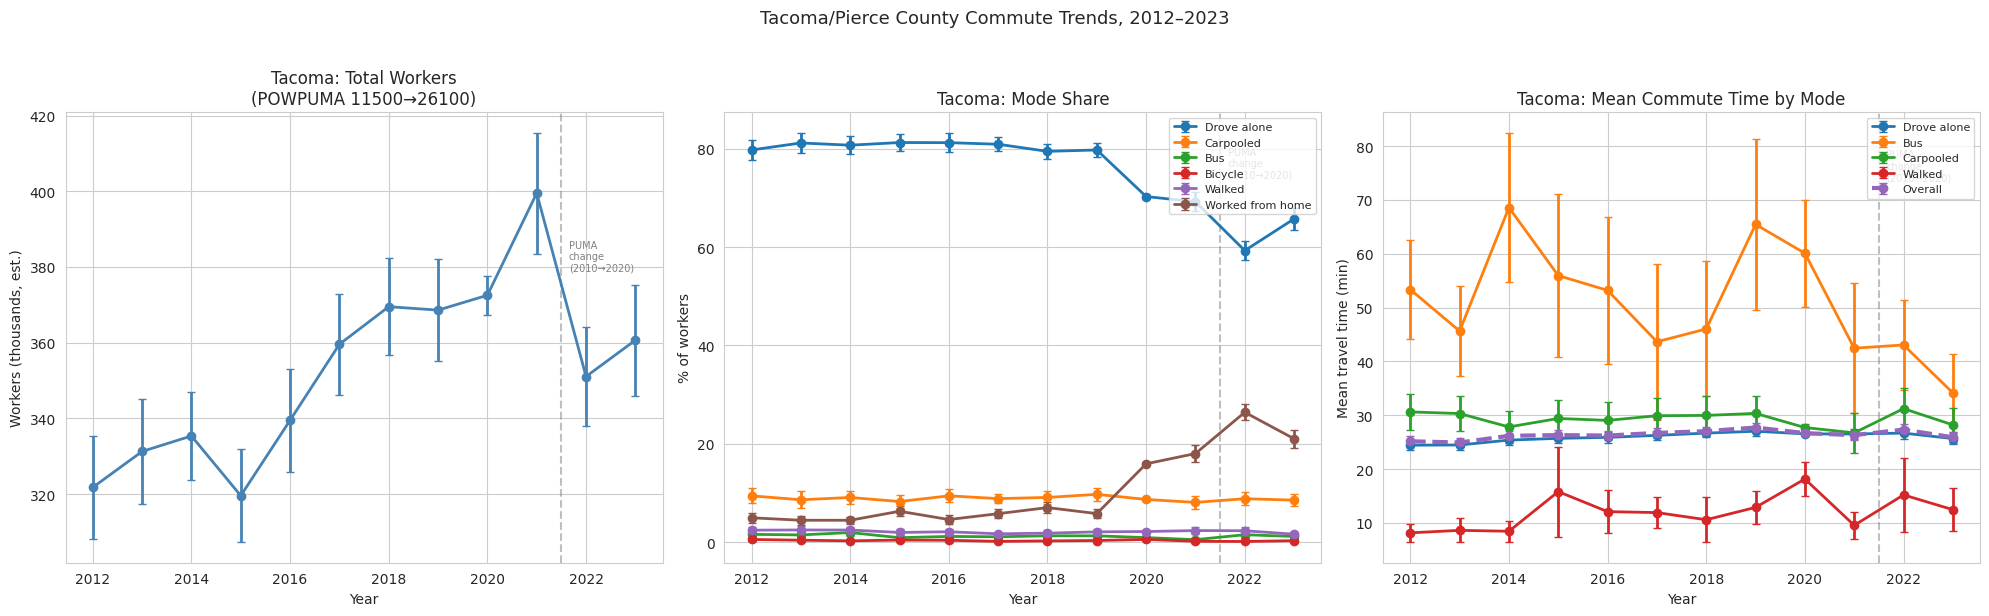

In [8]:
city = 'Tacoma'
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

plot_total_workers(axes[0], mode_trends[city], city, title_suffix='\n(POWPUMA 11500→26100)')
plot_mode_fractions(axes[1], mode_trends[city], city)
plot_travel_times(axes[2], time_trends[city], city)

plt.suptitle('Tacoma/Pierce County Commute Trends, 2012–2023', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

## Yakima (Yakima County)

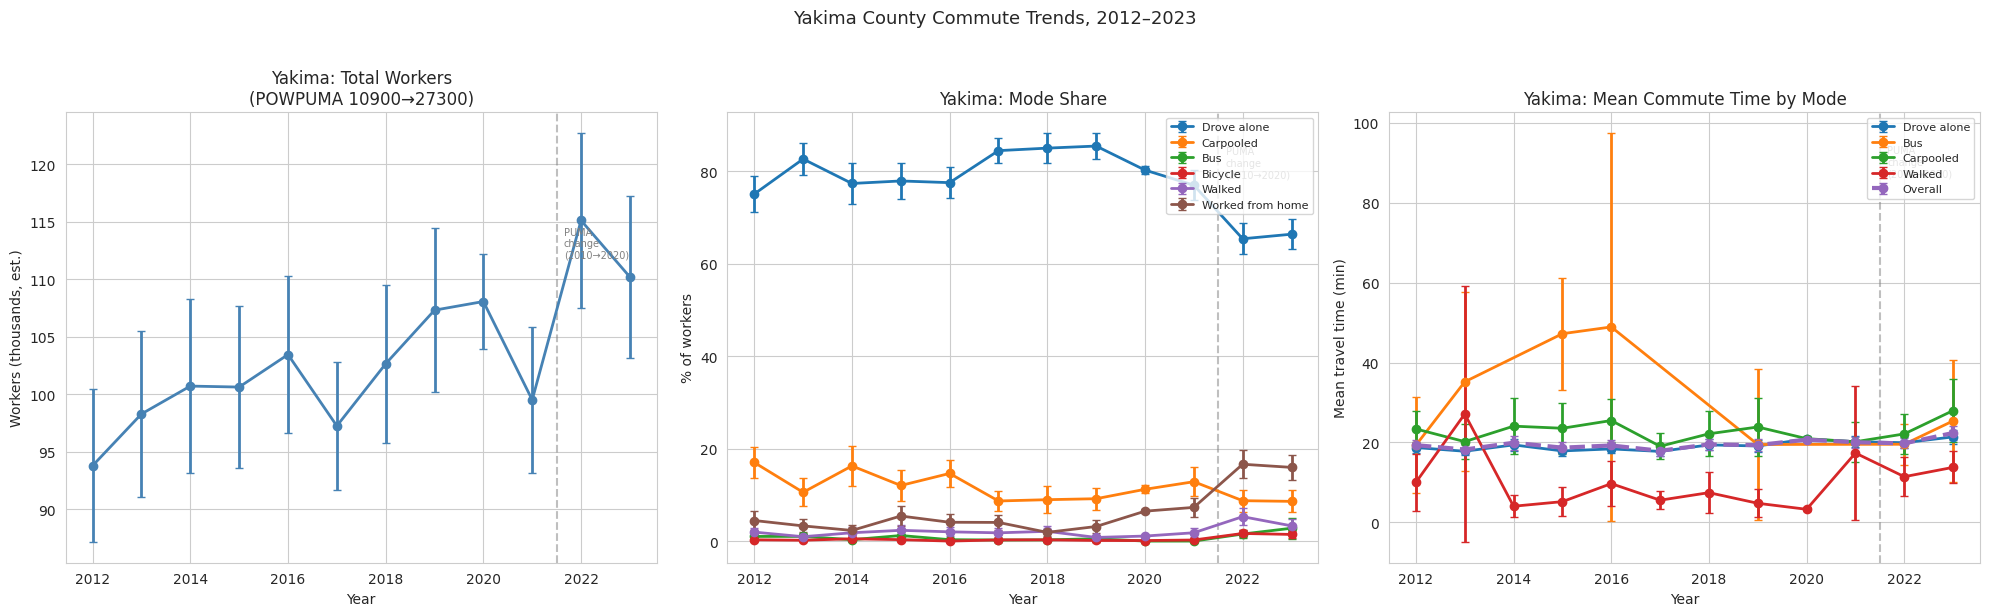

In [9]:
city = 'Yakima'
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

plot_total_workers(axes[0], mode_trends[city], city, title_suffix='\n(POWPUMA 10900→27300)')
plot_mode_fractions(axes[1], mode_trends[city], city)
plot_travel_times(axes[2], time_trends[city], city)

plt.suptitle('Yakima County Commute Trends, 2012–2023', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

## Summary: Overall mean commute time by city

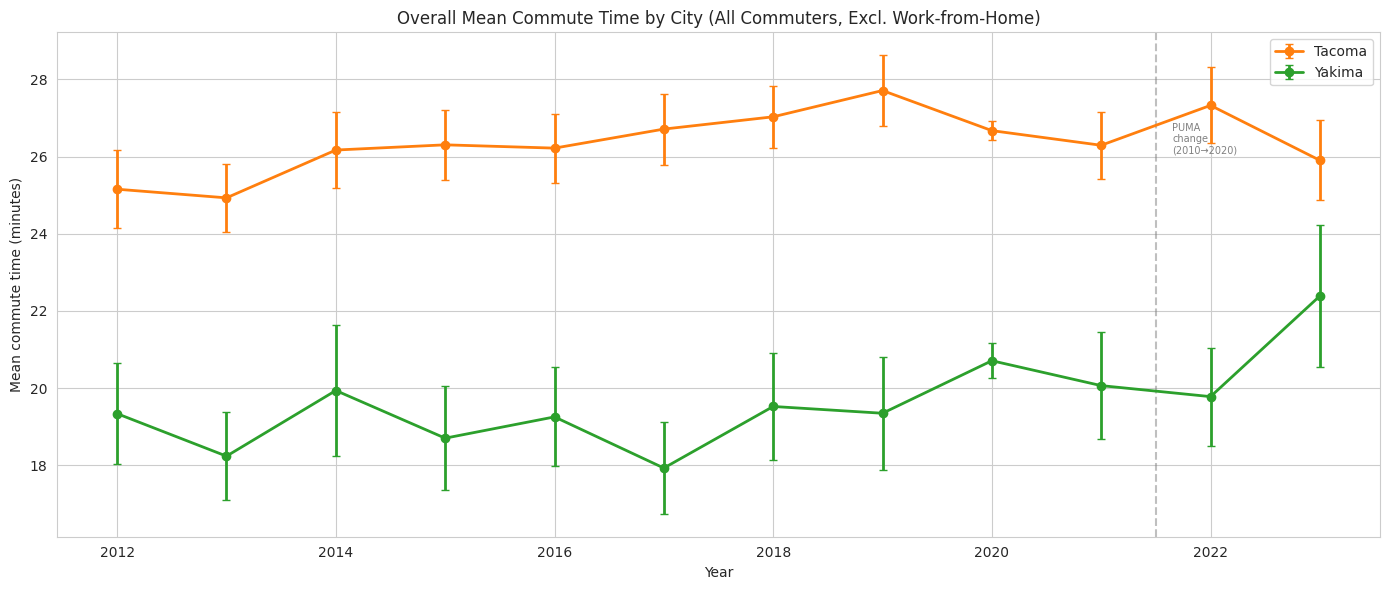

In [10]:
fig, ax = plt.subplots(figsize=(14, 6))

colors = {'Tacoma': 'tab:orange', 'Yakima': 'tab:green'}
for city in CITIES:
    sub = time_trends[city][time_trends[city]['mode'] == 'Overall'].sort_values('year')
    ax.errorbar(sub['year'], sub['mean_min'],
                yerr=1.96 * sub['se'],
                marker='o', capsize=3, label=city, linewidth=2, color=colors[city])

ax.set_xlabel('Year')
ax.set_ylabel('Mean commute time (minutes)')
ax.set_title('Overall Mean Commute Time by City (All Commuters, Excl. Work-from-Home)')
ax.legend()
add_puma_break(ax)
plt.tight_layout()
plt.show()

## Summary table — most recent year

In [11]:
latest_year = 2023
for city in CITIES:
    modes = mode_trends[city][mode_trends[city]['year'] == latest_year].copy()
    modes = modes.sort_values('n_weighted', ascending=False)
    times = time_trends[city][time_trends[city]['year'] == latest_year][['mode','mean_min']]
    summary = modes.merge(times, on='mode', how='left')
    summary['fraction_pct'] = (100 * summary['fraction']).round(1)
    summary['n_weighted'] = summary['n_weighted'].round(0).astype(int)
    summary['mean_min'] = summary['mean_min'].round(1)
    print(f'\n{city} — {latest_year}:')
    print(summary[['mode','n_weighted','fraction_pct','mean_min']]
          .rename(columns={'mode':'Mode','n_weighted':'Workers','fraction_pct':'Share (%)','mean_min':'Avg time (min)'})
          .to_string(index=False))


Tacoma — 2023:
            Mode  Workers  Share (%)  Avg time (min)
     Drove alone   237085       65.7            25.7
Worked from home    75890       21.0             NaN
       Carpooled    30899        8.6            28.2
          Walked     5945        1.6            12.4
           Other     5007        1.4             NaN
             Bus     4275        1.2            34.1
         Bicycle     1190        0.3            24.4
           Ferry      362        0.1           112.2
  Rail/streetcar        0        0.0             NaN

Yakima — 2023:
            Mode  Workers  Share (%)  Avg time (min)
     Drove alone    73179       66.4            21.4
Worked from home    17574       15.9             NaN
       Carpooled     9472        8.6            28.0
          Walked     3632        3.3            13.8
             Bus     3064        2.8            25.4
           Other     1618        1.5             NaN
         Bicycle     1587        1.4            26.6
  Rail/streetc